# FinTrust Week 2 — Exploratory Data Analysis
**Track:** Data Analytics | **Intern:** Miancy (Mercy Chepkemoi Koech)

This notebook explores FinTrust's customer and transaction data to uncover patterns in customer behaviour, transaction activity, channels, and risk.

In [2]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

server = r"localhost\SQLEXPRESS"
database = "FINTRUST DATABASES"

connection = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

customers = pd.read_sql("SELECT * FROM dbo.FinTrust_Customer_Data", connection)
transactions = pd.read_sql("SELECT * FROM dbo.FinTrust_Transaction_Data", connection)

connection.close()

print(customers.shape)
print(transactions.shape)

C:\Users\User\AppData\Local\Temp\ipykernel_11156\666537479.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("SELECT * FROM dbo.FinTrust_Customer_Data", connection)
C:\Users\User\AppData\Local\Temp\ipykernel_11156\666537479.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions = pd.read_sql("SELECT * FROM dbo.FinTrust_Transaction_Data", connection)


(1500, 12)
(12000, 11)


## 1. Customer Segment Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_11156\1451911133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='Blues_d')


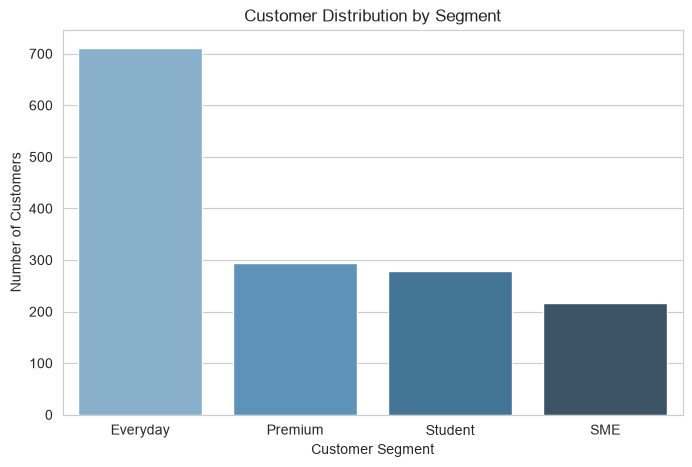

In [3]:
plt.figure(figsize=(8,5))
segment_counts = customers['Customer_Segment'].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='Blues_d')
plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()

**What it shows:** The number of customers in each segment (Everyday, Premium, SME, Student).
**Why it matters:** Segment size affects how FinTrust should prioritize resources and campaigns.
**Insight:** Everyday customers dominate the base at ~700 (nearly half of all 1,500 customers), while Premium (~295) and Student (~280) are roughly equal in size, and SME is the smallest (~230). This confirms FinTrust's core customer base is mass-market rather than concentrated in high-value segments, reinforcing the Week 1/SQL finding that Everyday drives the most transaction value — it's both the largest and most active segment.

## 2. Transaction Amount Distribution

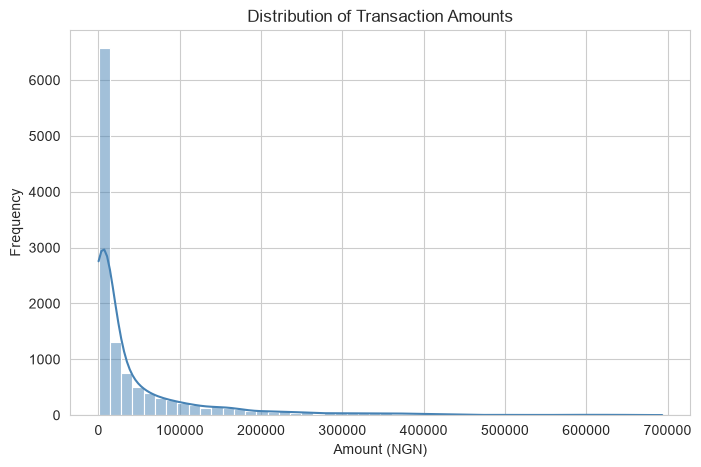

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(transactions['Amount_NGN'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount (NGN)')
plt.ylabel('Frequency')
plt.show()

**What it shows:** How transaction amounts are distributed across all 12,000 transactions.
**Why it matters:** The shape of this distribution affects which statistics (mean vs. median) best represent "typical" transaction behaviour, and reveals how common small vs. large transactions are.
**Insight:** The distribution is heavily right-skewed — the vast majority of transactions cluster under ₦50,000, with a sharp peak in the lowest bucket, then a long tail stretching out to ~₦693,000. This confirms the Week 2 Excel finding (mean ₦46,706 pulled well above the likely lower median) and means average transaction value alone would overstate what a "typical" customer transaction looks like. For reporting, median or segmented averages give a more honest picture than the mean alone.


## 3. Transaction Volume by Channel

C:\Users\User\AppData\Local\Temp\ipykernel_11156\4087973673.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_counts.index, y=channel_counts.values, palette='Greens_d')


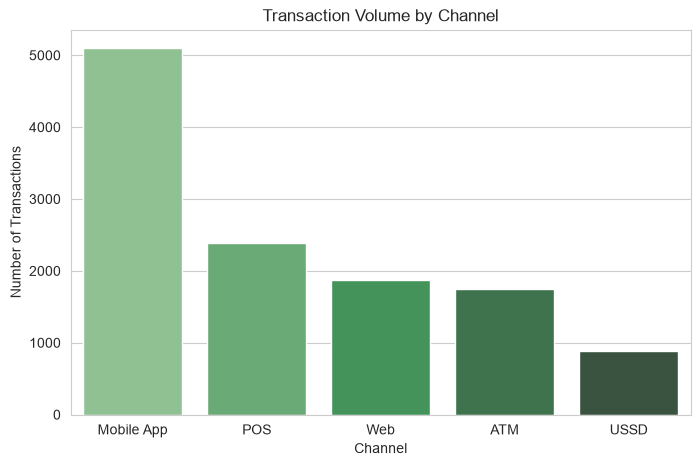

In [5]:
plt.figure(figsize=(8,5))
channel_counts = transactions['Channel'].value_counts()
sns.barplot(x=channel_counts.index, y=channel_counts.values, palette='Greens_d')
plt.title('Transaction Volume by Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Transactions')
plt.show()

**What it shows:** How many transactions occurred through each channel (Mobile App, POS, Web, ATM, USSD).
**Why it matters:** Channel usage patterns should guide where FinTrust invests in platform reliability, UX improvements, and support resources.
**Insight:** Mobile App dominates with ~5,100 transactions — more than double the next-highest channel (POS, ~2,400) — confirming FinTrust customers are primarily digital-first. USSD trails significantly at under 900 transactions, which may reflect either lower demand or a smaller segment of customers who rely on it (often those with limited smartphone/data access). Given Mobile App's outsized share, any reliability or performance issues there would affect the largest number of customers.

## 4. Risk Review Rate: Domestic vs. International Transactions

C:\Users\User\AppData\Local\Temp\ipykernel_11156\2569081837.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_by_intl.index, y=risk_by_intl.values, palette='Reds_d')


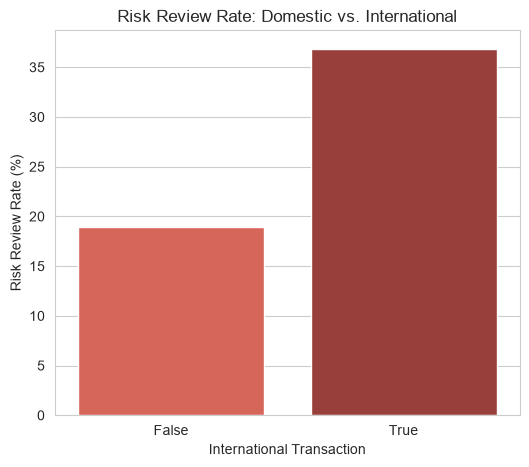

In [7]:
risk_by_intl = transactions.groupby('International_Transaction')['Risk_Review_Flag'].apply(
    lambda x: (x == 1).mean() * 100
)

plt.figure(figsize=(6,5))
sns.barplot(x=risk_by_intl.index, y=risk_by_intl.values, palette='Reds_d')
plt.title('Risk Review Rate: Domestic vs. International')
plt.xlabel('International Transaction')
plt.ylabel('Risk Review Rate (%)')
plt.show()

**What it shows:** The percentage of transactions flagged for risk review, split by whether the transaction was domestic (False) or international (True).
**Why it matters:** This directly tests whether international transactions carry meaningfully higher risk — a key input for how FinTrust allocates risk-monitoring resources.
**Insight:** International transactions are flagged at nearly double the rate of domestic ones (~36.9% vs. ~18.9%), despite making up a small share of total transaction volume. This is the strongest risk signal in the dataset and supports a clear recommendation: FinTrust's risk-review process should weight international transactions more heavily, and any automated risk-scoring model should treat this as a high-importance feature.

## 5. Transaction Status Breakdown

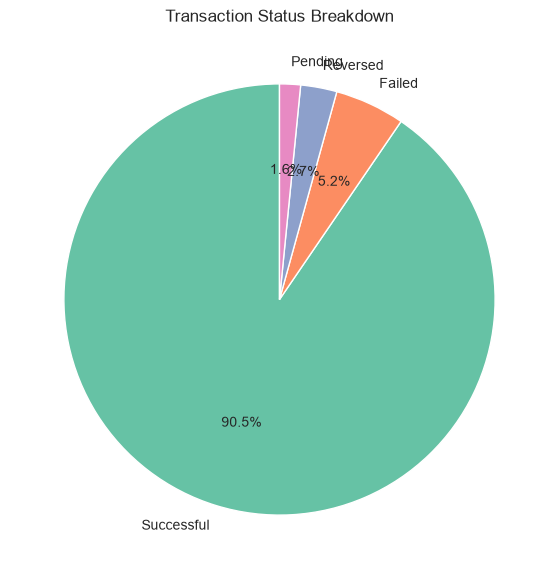

In [8]:
plt.figure(figsize=(7,7))
status_counts = transactions['Transaction_Status'].value_counts()
colors = sns.color_palette('Set2')
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Transaction Status Breakdown')
plt.show()

**What it shows:** The proportion of all transactions by final status (Successful, Failed, Reversed, Pending).
**Why it matters:** Failed and reversed transactions represent friction — customers whose attempted transactions didn't go through cleanly, which can drive support load and erode trust in the platform.
**Insight:** While 90.5% of transactions succeed, the combined 7.9% that are Failed or Reversed (630 + 326 transactions) is a meaningful volume worth investigating — is it concentrated in a particular channel or transaction type? This is a natural follow-up question for Week 3, and a metric FinTrust should track as a reliability KPI going forward.

## Summary of Key Findings

1. **Everyday segment dominates** the customer base (~700 customers) and generates the most transaction value — FinTrust's core business is mass-market, not premium-concentrated.
2. **Transaction amounts are heavily right-skewed** — most transactions are small, with a long tail of high-value outliers; median is more representative than mean.
3. **Mobile App is the dominant channel** (~5,100 transactions), more than double any other channel — platform reliability here has outsized impact.
4. **International transactions carry significantly higher risk** — flagged at ~36.9% vs. ~18.9% for domestic, the strongest risk signal in the dataset.
5. **7.9% of transactions fail or reverse** — a real operational friction point worth deeper investigation in Week 3.

These findings feed directly into the KPI framework and dashboard planned for Week 3.

# Part C — Advanced Python Analysis
Extending the Week 2 EDA with deeper, comparative, and trend analysis — validating key findings from the Week 3 advanced SQL work.

## 1. Transaction Volume by Day of Week

C:\Users\User\AppData\Local\Temp\ipykernel_13560\390193794.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='Purples_d')


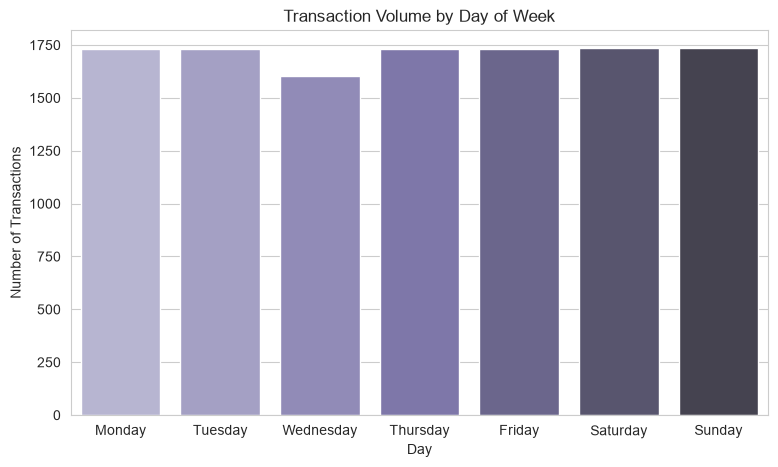

In [3]:
transactions['Transaction_DateTime'] = pd.to_datetime(transactions['Transaction_DateTime'])
transactions['Day_Of_Week'] = transactions['Transaction_DateTime'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = transactions['Day_Of_Week'].value_counts().reindex(day_order)

plt.figure(figsize=(9,5))
sns.barplot(x=day_counts.index, y=day_counts.values, palette='Purples_d')
plt.title('Transaction Volume by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Transactions')
plt.show()

**What it shows:** Transaction volume across each day of the week.
**Why it matters:** Validates whether the Week 2 monthly dip (Feb) is explained by a recurring weekly pattern.
**Insight:** Volume is remarkably even across all 7 days (no strong weekday/weekend split), confirming the SQL finding — there's no weekly cycle hiding in the data, which means the Feb dip is more likely a genuine month-level fluctuation than a structural pattern.

## 2. Risk Rate Heatmap: Channel × International Status

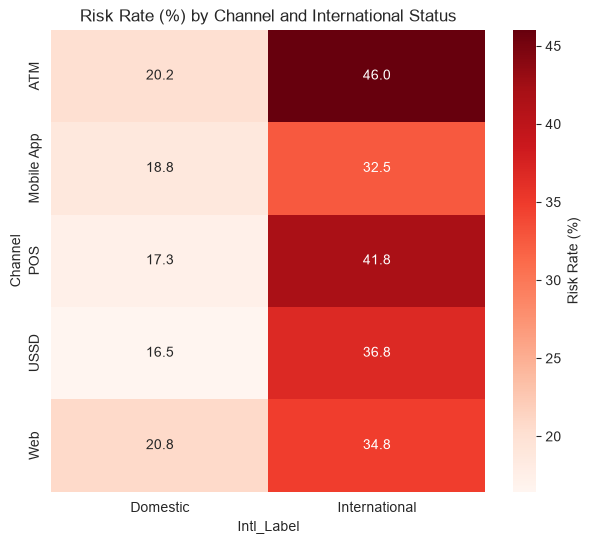

In [6]:
transactions['Intl_Label'] = transactions['International_Transaction'].map({True:'International', False:'Domestic'})
transactions['Risk_Numeric'] = transactions['Risk_Review_Flag'].astype(int)  # convert True/False to 1/0 for averaging

risk_pivot = transactions.pivot_table(
    values='Risk_Numeric', index='Channel', columns='Intl_Label', aggfunc='mean'
) * 100

plt.figure(figsize=(7,6))
sns.heatmap(risk_pivot, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label':'Risk Rate (%)'})
plt.title('Risk Rate (%) by Channel and International Status')
plt.show()

**What it shows:** Risk-flag rate for every combination of channel and domestic/international status.
**Why it matters:** Tests whether risk factors compound, and pinpoints exactly which combinations are highest-risk — more precise than looking at channel or international status separately.
**Insight:** ATM + International is the single highest-risk combination at 46.0% — nearly 2.5x the ATM domestic rate (20.2%). Every channel shows a similar pattern: international transactions roughly double or more the domestic risk rate on that same channel. This confirms and sharpens the SQL finding (40.15% for combined Web/ATM) — ATM alone is actually the riskiest channel for international transactions, higher than Web (34.8%). FinTrust's risk model should treat "international + ATM" as its highest-priority combination for review.

## 3. Customer Spend vs. Transaction Frequency


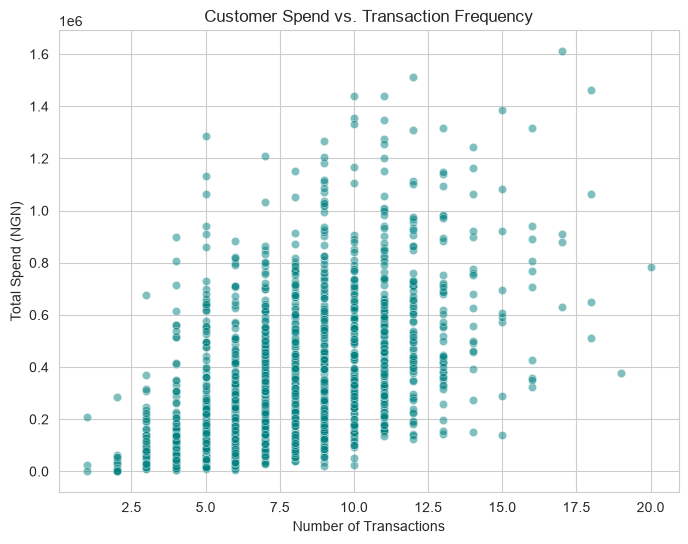

In [7]:
customer_summary = transactions.groupby('Customer_ID').agg(
    Txn_Count=('Transaction_ID', 'count'),
    Total_Spend=('Amount_NGN', 'sum')
).reset_index()

plt.figure(figsize=(8,6))
sns.scatterplot(data=customer_summary, x='Txn_Count', y='Total_Spend', alpha=0.5, color='teal')
plt.title('Customer Spend vs. Transaction Frequency')
plt.xlabel('Number of Transactions')
plt.ylabel('Total Spend (NGN)')
plt.show()

**What it shows:** Each dot is one customer, plotted by how many transactions they made vs. their total spend.
**Why it matters:** Tests whether "high spender" and "frequent transactor" are the same customer type, or genuinely different behaviours.
**Insight:** There is no clean linear relationship — customers reach high total spend (₦1M+) across a wide range of transaction counts, from as few as 5 to as many as 17+. Several of the highest-spending customers achieve this with relatively few transactions (large individual amounts), while others reach similar totals through many smaller ones. This confirms the SQL Q4 finding: FinTrust has at least two distinct high-value customer behaviours — "big-ticket, infrequent" and "frequent, moderate-value" — which likely warrant different engagement strategies (e.g. relationship banking vs. loyalty/rewards programs).

## 4. Transaction Type Value by Customer Segment

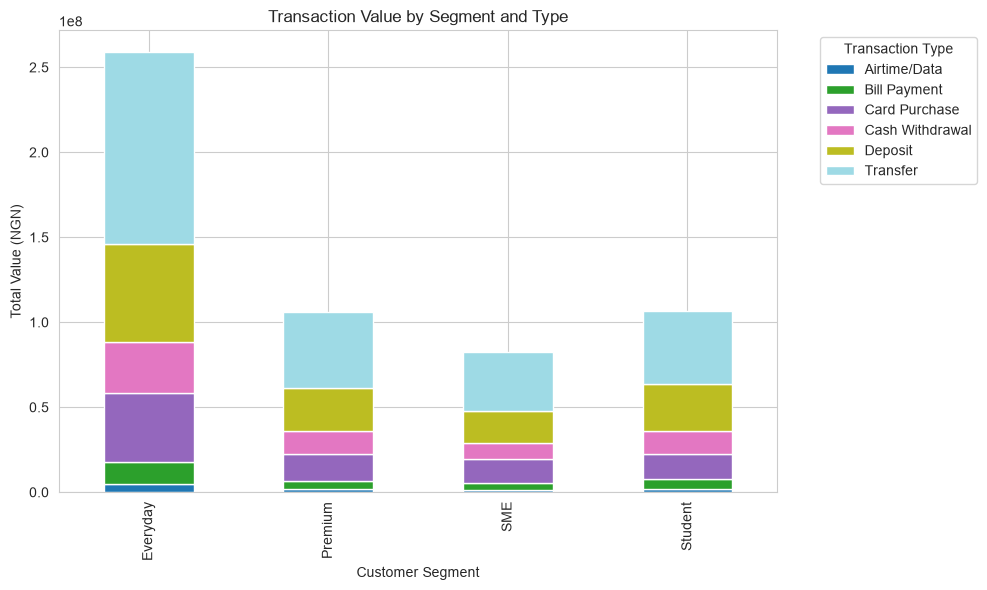

In [9]:
pivot = transactions.merge(customers[['Customer_ID','Customer_Segment']], on='Customer_ID')
segment_type = pivot.pivot_table(values='Amount_NGN', index='Customer_Segment', columns='Transaction_Type', aggfunc='sum')

segment_type.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.title('Transaction Value by Segment and Type')
plt.xlabel('Customer Segment')
plt.ylabel('Total Value (NGN)')
plt.legend(title='Transaction Type', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

**What it shows:** Total transaction value by type (Transfer, Deposit, Card Purchase, etc.), stacked and broken down by customer segment.
**Why it matters:** Confirms whether Transfer's dominance (found in aggregate in Week 2) holds true within every individual segment, or whether it's just an artifact of Everyday's large size.
**Insight:** Transfer is the largest component in every single segment's bar, not just in the overall aggregate — confirming this is a universal customer behaviour across FinTrust's base, not something driven by one segment. Interestingly, Premium and Student segments show nearly identical total bar heights (~₦1.06M scale), despite Premium typically being assumed the "higher-value" segment — this nuance, visible here, matches the SQL finding and is worth highlighting as a finding on its own.

## 5. Transaction Success Rate by Value Range

C:\Users\User\AppData\Local\Temp\ipykernel_13560\3991904376.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=success_by_range.index, y=success_by_range.values, palette='Blues_d')


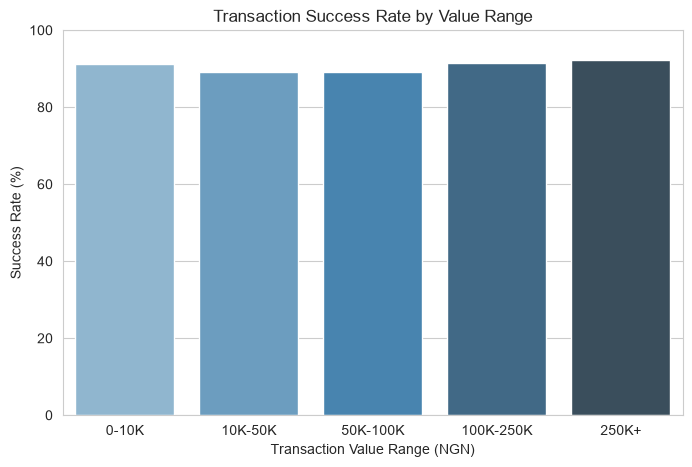

In [10]:
bins = [0, 10000, 50000, 100000, 250000, transactions['Amount_NGN'].max()]
labels = ['0-10K', '10K-50K', '50K-100K', '100K-250K', '250K+']
transactions['Value_Range'] = pd.cut(transactions['Amount_NGN'], bins=bins, labels=labels)

success_by_range = transactions.groupby('Value_Range')['Transaction_Status'].apply(
    lambda x: (x == 'Successful').mean() * 100
)

plt.figure(figsize=(8,5))
sns.barplot(x=success_by_range.index, y=success_by_range.values, palette='Blues_d')
plt.title('Transaction Success Rate by Value Range')
plt.xlabel('Transaction Value Range (NGN)')
plt.ylabel('Success Rate (%)')
plt.ylim(0,100)
plt.show()

**What it shows:** Transaction success rate across five value ranges, from under ₦10K to over ₦250K.
**Why it matters:** Tests whether failures/reversals are driven by transaction size — if larger transactions failed more often, that would point to a different root cause (e.g. insufficient funds, fraud checks) than if failure is evenly spread.
**Insight:** Success rate is remarkably stable across all value ranges (88-92%), with no clear downward trend as value increases — in fact, the highest-value range (250K+) has the *highest* success rate (~92%). This rules out transaction size as a driver of the ~8% failure/reversal rate found in Week 2 and the USSD-specific pattern found in Week 3 Q1 — failures appear to be a channel/platform issue rather than a value-related one (e.g. insufficient funds), reinforcing that the USSD reliability finding is the more useful lead to act on.

## Summary of Advanced Python Findings

1. **No weekly pattern** — transaction volume is even across all 7 days, confirming the Week 2 monthly dip is a genuine fluctuation, not a recurring cycle.
2. **Risk factors compound sharply** — ATM + International is the single riskiest combination (46.0%), more than double ATM's domestic rate (20.2%).
3. **Spend and frequency are distinct behaviours** — high-value customers reach similar totals through very different transaction patterns (few large vs. many small).
4. **Transfer dominates every segment individually**, not just in aggregate — a universal customer behaviour.
5. **Transaction value does not predict failure** — success rate is stable (88-92%) regardless of transaction size, ruling out value as a driver of the Week 2 failure/reversal finding.

These validate and sharpen every major Week 2 finding, and point clearly toward USSD reliability and the ATM+International risk combination as the two most actionable issues for Week 4.